# A* Path Planning Algorithm

The A* (A-star) algorithm is a widely used and highly effective pathfinding and graph traversal algorithm. It is heavily utilized in robotics for navigating 2D occupancy grids (like planning a route for a mobile robot avoiding obstacles).

A* selects the path that minimizes the total estimated cost, evaluating nodes based on the following function:
**f(n) = g(n) + h(n)**

* **g(n)**: The exact cost of the path from the starting node to the current node 'n'.
* **h(n)**: The heuristic estimated cost from node 'n' to the goal. This must be an "admissible" heuristic, meaning it never overestimates the true cost.

This notebook implements A* on a 2D grid, using the Euclidean distance as the heuristic to find the shortest path from a start position to a goal position while avoiding obstacles.

## Part 1: Node Definition and Heuristics

First, we define a `Node` class. This allows us to keep track of a node's position on our grid, its parent (so we can retrace the final path), and its specific costs (`g`, `h`, and `f`). 

We will also define a heuristic function. Since our robot can move in 8 directions (including diagonals), Euclidean distance provides a straightforward and admissible heuristic.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

class Node:
    #initialize the node with an optional parent node and a position
    def __init__(self,parent=None,position=None):
        self.parent=parent #the node object we came from
        self.position=position # position is (row, col). 
        # row corresponds to vertical axis, col to horizontal.

        self.g=0 #distance to start node
        self.h=0 #distance to goal node
        self.f=0 #total cost g+h


    # Define equality so we can easily check if two nodes share the same position
    def __eq__(self, other):
        return self.position==other.position

def heuristic(current_pos,goal_pos):
    #calculate the euclidean distance between two points
    #both inputs are tuples representing coordinates
    return np.sqrt((current_pos[0]-goal_pos[0])**2+(current_pos[1]-goal_pos[1])**2)

    

## Part 2: The A* Search Algorithm

The core logic maintains two lists:
1. **Open List**: Nodes that have been discovered but not yet evaluated.
2. **Closed List**: Nodes that have already been evaluated.

The algorithm loops by continually pulling the node with the lowest `f` cost from the open list, generating its neighbors, and evaluating them. If a neighbor is the goal, we trace the `parent` pointers back to the start to get the final path.

In [11]:
def astar(maze,start,goal):
    #maze is a 2d numpy array where 0 is a free space and 1 is an obstacle
    #start:tuple of the start pos, end: tuple of the end pos

    #create start and goal nodes
    start_node=Node(None,start)
    start_node.g=start_node.h=start_node.f=0
    goal_node=Node(None,goal)
    goal_node.g=goal_node.h=goal_node.f=0

    #initialize open and closed lists
    open_list=[] # list of node objects
    closed_list=[] #list of node objs

    #add the start node to the open list
    open_list.append(start_node)

    #loop till the open list is empty or we find the goal
    while len(open_list)>0:

        #get the current node with the lowest f cost
        current_node=open_list[0]
        current_index=0
        for index,item in enumerate(open_list):
            if item.f<current_node.f:
                current_node=item
                current_index=index
    
        #pop current off open list, and add it to closed list
        open_list.pop(current_index)
        closed_list.append(current_node)

        #check if we found the goal
        if current_node==goal_node:
            path=[]
            current=current_node
            #retrace the path backwards
            while current is not None:
                path.append(current.position)
                current=current.parent

            return path[::-1]#reverse path so that it goes from start to goal
        
        #generate children/adjacent nodes
        children=[]

        # These 8 tuples represent the relative movements: up, down, left, right, and the 4 diagonals
        for new_position in [(0,-1),(0,1),(-1,0),(1,0),(-1,-1),(-1,1),(1,1),(1,-1)]:

            #get the exact node position
            node_position=(current_node.position[0]+new_position[0],current_node.position[1]+new_position[1])
            # Make sure the new position is within the bounds of the maze (e.g., inside the 10x10 grid)
            if node_position[0] > (len(maze) - 1) or node_position[0] < 0 or node_position[1] > (len(maze[len(maze)-1]) -1) or node_position[1] < 0:
                continue

            # Make sure the new position is walkable terrain (0 = free, 1 = obstacle)
            if maze[node_position[0]][node_position[1]] != 0:
                continue

            new_node=Node(current_node,node_position)
            children.append(new_node)

        #loop through the generated childrens
        for child in children:

            #if the child is already in the closed list,skip it
            if len([closed_child for closed_child in closed_list if closed_child==child])>=1:
                continue
            #calculate the f,g, and h value
            child.g=current_node.g+heuristic(current_node.position,child.position)
            child.h=heuristic(child.position,goal_node.position)
            child.f=child.g+child.h

            # If the child is already in the open list with a lower g cost, ignore this path
            if len([open_node for open_node in open_list if child == open_node and child.g > open_node.g]) > 0:
                continue

            #add it to the open list
            open_list.append(child)
    return None





## Part 3: Setup Map, Run Algorithm, and Visualize

Now we define a sample map matrix. We will use `matplotlib.pyplot` to visualize the grid, highlighting the start, the goal, and the path returned by our A* function.

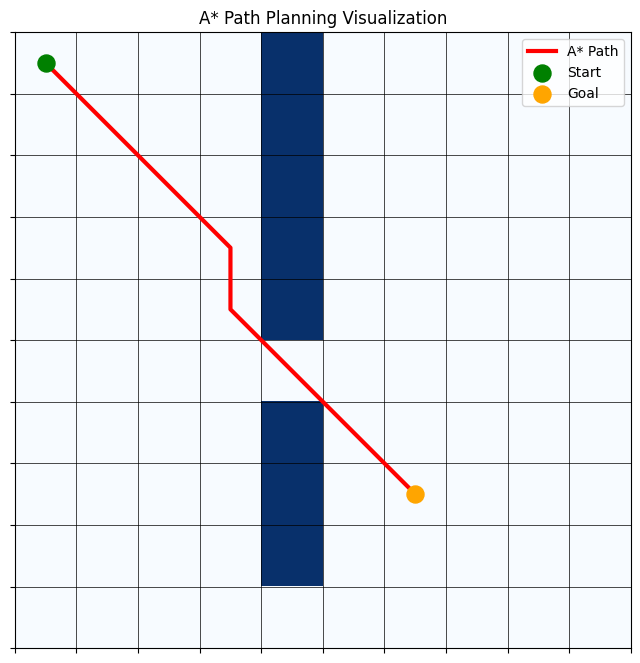

In [12]:
def visualize_path(maze, path, start, goal):
    # Convert maze to numpy array for easier plotting
    grid = np.array(maze)
    
    # Create the plot figure
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Display the grid using a colormap (Blues)
    # Obstacles (1s) will show up darker, free space (0s) will be lighter
    ax.imshow(grid, cmap='Blues')
    
    if path:
        # Extract the row and column coordinates from the path tuples
        # Example path: [(0,0), (1,1), (2,2)] -> y=[0,1,2], x=[0,1,2]
        # Note: In plotting (row, col) usually maps to (y, x) 
        path_y = [p[0] for p in path]
        path_x = [p[1] for p in path]
        
        # Plot the path as a red line
        ax.plot(path_x, path_y, color='red', linewidth=3, label='A* Path')
    
    # Scatter plot for start (green) and goal (orange) points
    ax.scatter(start[1], start[0], color='green', s=150, label='Start', zorder=5)
    ax.scatter(goal[1], goal[0], color='orange', s=150, label='Goal', zorder=5)
    
    # Add gridlines and labels for clarity
    ax.grid(which='major', axis='both', linestyle='-', color='k', linewidth=0.5)
    ax.set_xticks(np.arange(-0.5, len(maze[0]), 1))
    ax.set_yticks(np.arange(-0.5, len(maze), 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.legend()
    ax.set_title("A* Path Planning Visualization")
    
    plt.show()

# --- Execution ---

# Define a 10x10 maze. 0 is free space, 1 is an obstacle.
maze = [[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # A gap in the wall
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]

# Define start and goal coordinates (row, col)
start_pos = (0, 0)
goal_pos = (7, 6)

# Run the algorithm
optimal_path = astar(maze, start_pos, goal_pos)

# Visualize the result
visualize_path(maze, optimal_path, start_pos, goal_pos)